In [1]:
import numpy as np
import jax.numpy as jnp
from jax.scipy.special import logsumexp
import jax
from jax import jit, vmap, pmap, grad, value_and_grad

In [2]:
# 1. The Step Function (Euler Integration)
def gctln_step(x, t, W, theta):
    dt = 0.05
    # dx/dt = -x + [Wx + theta]_+
    summation = jnp.dot(W, x) + theta
    dxdt = -x + jnp.maximum(0, summation)
    next_x = x + dxdt * dt 
    # Scan expects (carry, output). We carry the state to the next step.
    return next_x, next_x

# 2. The Differentiable Weight Mapper
def get_W(M, eps, delta):
    # We use sigmoid to keep edges between 0 and 1
    # A_ij ~ 1 means an edge exists (-1 + eps)
    # A_ij ~ 0 means no edge (-1 - delta)
    A = jax.nn.sigmoid(M)  ## Differentiable
    W = A * (-1 + eps) + (1 - A) * (-1 - delta)
    # Mask the diagonal (neurons don't inhibit themselves)
    W = W *  (1 - jnp.eye(M.shape[0]))
    return W

# 3. The Full Simulation
def simulate(M, x0, steps, eps, delta, theta):
    W = get_W(M, eps, delta)
    # scan(function, init_state, xs_to_iterate_over)
    _, trajectory = jax.lax.scan(
        lambda x, u: gctln_step(x, u, W, theta),
        x0,
        jnp.arange(steps)
    )
    return trajectory

@jax.jit(static_argnames=['steps'])
def robust_loss_fn(M, target_trajectory, x0_batch, steps):
    eps, delta, theta = 0.2, 0.5, 1.0
    
    # Simulate ALL 100 initial conditions at once
    # predictions shape: (100, steps, n_neurons)
    predictions = batch_simulate(M, x0_batch, steps, eps, delta, theta)
    
    # Calculate MSE across all trials and all time steps
    # We want EVERY trial to converge to the same target_trajectory
    return jnp.mean((predictions - target_trajectory)**2)


In [3]:
seed = 42
key = jax.random.PRNGKey(seed)
M = jax.random.normal(key, (5, 5)) * 0.1 - 2.0

print(M)

[[-2.0028305 -1.9532868 -1.9704297 -1.9846454 -2.0124032]
 [-1.9783077 -2.1440878 -1.924414  -1.947859  -1.908983 ]
 [-2.0384498 -1.8860177 -1.8554214 -1.8919094 -2.0056293]
 [-1.9090406 -1.9442654 -1.9780943 -2.144851  -1.9235812]
 [-2.0241547 -2.117938  -2.1938918 -1.9643736 -2.024112 ]]


In [4]:
n_neurons = 5
t = np.linspace(0, 20, 100)

x0 = jax.random.uniform(key, (5,), minval=0.1, maxval=0.5)

target = np.zeros((100, n_neurons))
for i in range(n_neurons):
    target[:, i] = np.exp(-(t - (i*5))**2 / 2) # Gaussian peaks

In [5]:
# We wrap the 'simulate' function you already wrote
# We tell vmap: "Don't vectorize M, eps, delta, or theta. Only vectorize x0."
# in_axes: (None, 0, None, None, None, None) 
# The '0' means we are mapping over the 0th axis of the 2nd argument (x0).
v_simulate = jax.vmap(simulate, in_axes=(None, 0, None, None, None, None))

# Now we can compile it for extreme speed
batch_simulate = jax.jit(v_simulate, static_argnums=(2,))

In [6]:
n_neurons = 5
n_trials = 100
key = jax.random.PRNGKey(42)

# Generate 100 random starting activity levels
# Each row is a different x0
x0_batch = jax.random.uniform(key, (n_trials, n_neurons), minval=0.0, maxval=1.0)

# Run all 100 simulations at once!
# The output 'trajectories' will have shape (100, steps, n_neurons)
trajectories = batch_simulate(M, x0_batch, 500, 0.2, 0.5, 1.0)

In [7]:
import optax

# Define the optimizer
optimizer = optax.adam(learning_rate=0.05)
opt_state = optimizer.init(M)

@jit(static_argnames=['steps'])
def train_step(M, opt_state, target, x0, steps):
    # Calc loss and grads in one go
    loss_value, grads = jax.value_and_grad(robust_loss_fn)(M, target, x0, steps)

    # Update M based on grads
    updates, opt_state = optimizer.update(grads, opt_state)
    M = optax.apply_updates(M, updates)

    return M, opt_state, loss_value

steps = 100 # Time steps not training steps

# Run the loop
for i in range(200):
    M, opt_state, loss = train_step(M, opt_state, target, x0_batch, steps)
    if i % 20 == 0:
        print(f"Iteration {i}, Loss: {loss:.6f}")

Iteration 0, Loss: 0.102649
Iteration 20, Loss: 0.096852
Iteration 40, Loss: 0.092643
Iteration 60, Loss: 0.090634
Iteration 80, Loss: 0.088712
Iteration 100, Loss: 0.087841
Iteration 120, Loss: 0.087296
Iteration 140, Loss: 0.087045
Iteration 160, Loss: 0.086919
Iteration 180, Loss: 0.086828


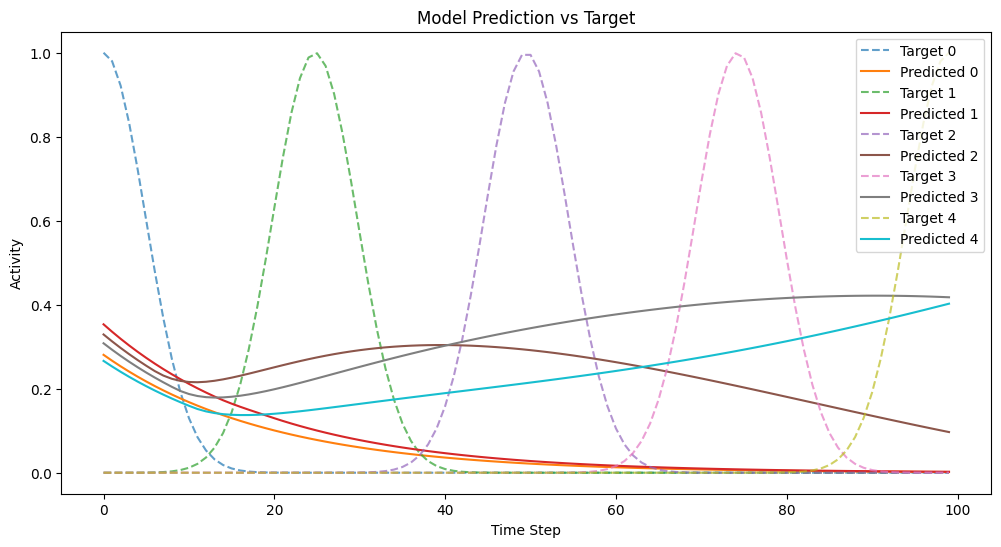

In [8]:
import matplotlib.pyplot as plt

# Hyperparams (same as loss_fn)
eps = 0.2
delta = 0.5
theta = 1.0

# Run simulation with trained weights
prediction = simulate(M, x0, steps, eps, delta, theta)

# Plotting
plt.figure(figsize=(12, 6))
for i in range(n_neurons):
    plt.plot(target[:, i], label=f'Target {i}', linestyle='--', alpha=0.7)
    plt.plot(prediction[:, i], label=f'Predicted {i}')

plt.title("Model Prediction vs Target")
plt.xlabel("Time Step")
plt.ylabel("Activity")
plt.legend()
plt.show()

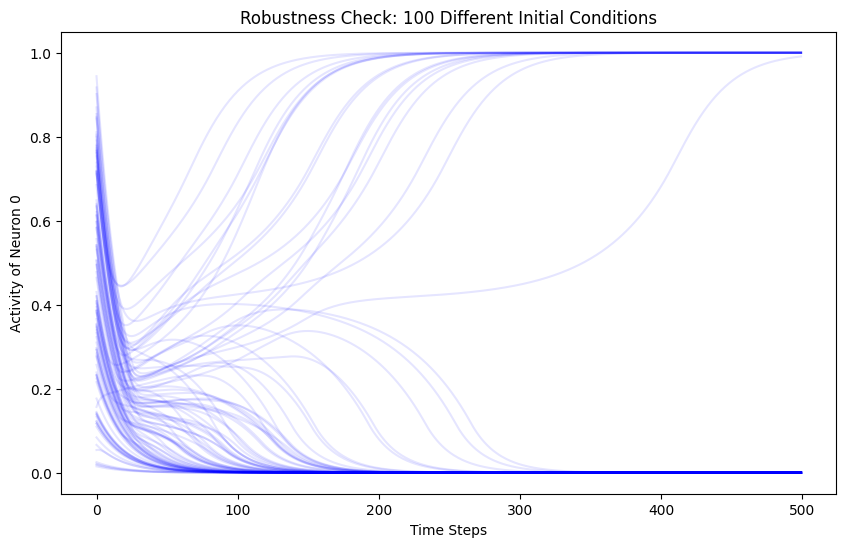

In [9]:
plt.figure(figsize=(10, 6))
# Plot only the first neuron for all 100 trials
for i in range(n_trials):
    plt.plot(trajectories[i, :, 0], color='blue', alpha=0.1)

plt.title("Robustness Check: 100 Different Initial Conditions")
plt.xlabel("Time Steps")
plt.ylabel("Activity of Neuron 0")
plt.show()

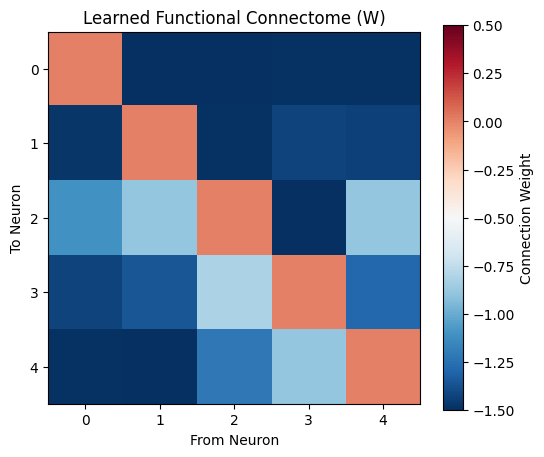

In [10]:
def plot_circuit(M, eps=0.2, delta=0.5):
    # Convert optimized M to the actual weights W
    W = get_W(M, eps, delta)
    
    plt.figure(figsize=(6, 5))
    plt.imshow(W, cmap='RdBu_r', vmin=-1.5, vmax=0.5)
    plt.colorbar(label='Connection Weight')
    plt.title("Learned Functional Connectome (W)")
    plt.xlabel("From Neuron")
    plt.ylabel("To Neuron")
    plt.show()

plot_circuit(M)

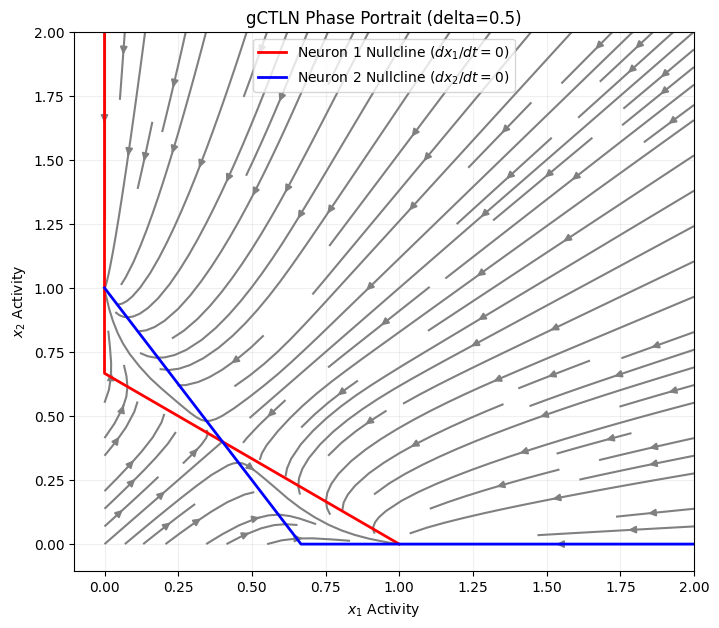

In [11]:
import matplotlib.pyplot as plt

def plot_gctln_phase_portrait(epsilon=0.25, delta=0.5, theta=1.0):
    # 1. Define a 2-neuron weight matrix (Mutual Inhibition)
    # Both neurons inhibit each other with -1 - delta
    # No "edges" (epsilon) yet for simplicity
    W = jnp.array([[0, -1 - delta], 
                   [-1 - delta, 0]])
    
    # 2. Create a grid of points (x1, x2)
    x_range = jnp.linspace(0, 2, 20)
    y_range = jnp.linspace(0, 2, 20)
    X1, X2 = jnp.meshgrid(x_range, y_range)
    
    # 3. Calculate Vector Field (dx/dt)
    U = -X1 + jnp.maximum(0, W[0, 1] * X2 + theta)
    V = -X2 + jnp.maximum(0, W[1, 0] * X1 + theta)
    
    # 4. Plotting
    plt.figure(figsize=(8, 7))
    # FIX: Cast JAX arrays to Numpy arrays for streamplot
    plt.streamplot(np.array(X1), np.array(X2), np.array(U), np.array(V), color='gray')
    
    # Calculate Nullclines for plotting
    # Neuron 1 Nullcline: x1 = max(0, W01*x2 + theta)
    # Neuron 2 Nullcline: x2 = max(0, W10*x1 + theta)
    x_vals = jnp.linspace(0, 2, 100)
    nc1 = jnp.maximum(0, W[0, 1] * x_vals + theta)
    nc2 = jnp.maximum(0, W[1, 0] * x_vals + theta)
    
    plt.plot(nc1, x_vals, 'r-', linewidth=2, label='Neuron 1 Nullcline ($dx_1/dt=0$)')
    plt.plot(x_vals, nc2, 'b-', linewidth=2, label='Neuron 2 Nullcline ($dx_2/dt=0$)')
    
    plt.xlabel('$x_1$ Activity')
    plt.ylabel('$x_2$ Activity')
    plt.title(f"gCTLN Phase Portrait (delta={delta})")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

plot_gctln_phase_portrait()